# Covtype detector comparison inside STUDD

This notebook compares different drift detectors inside the STUDD mechanism on the Covtype dataset.

Covtype does not provide a known ground-truth drift point.

Following the evaluation protocol used for real datasets, we use the first alarm produced by the supervised signal detector (SS) as a reference drift indication.

For each STUDD detector, we record:

- all STUDD alarms
- the STUDD alarm closest to the first SS alarm
- teacher accuracy around the first SS alarm
- teacher-student disagreement around the first SS alarm
- teacher accuracy around the closest STUDD alarm
- teacher-student disagreement around the closest STUDD alarm

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from capymoa.datasets import Covtype

from capymoa.drift.detectors import (
    STUDD,
    ADWIN,
    PageHinkley,
    HDDMAverage,
    HDDMWeighted,
    CUSUM,
)

from helpers import (
    configure_matplotlib,
    rolling_mean,
)

from studd_utils import (
    make_teacher,
    make_student,
    collect_instances,
)

configure_matplotlib()

## Experimental parameters

The full Covtype stream is used.

The teacher is trained on the first `W` labeled samples and remains fixed during monitoring.

The student learns to mimic the teacher, while STUDD monitors teacher-student agreement.

The first SS alarm is used as the reference drift indication.

In [2]:
SEED = 42

W = 2000
N_STREAM = 581012  

N_TREES = 100
TEACHER_TYPE = "lr"
STUDENT_TYPE = "lr"

LOCAL_WINDOW = 100
ROLLING_WINDOW = 200

## Stream size

The original Covtype stream contains 581,012 observations.

Unlike the original STUDD paper, which truncated very large streams to 100,000 observations, the full stream is used in this work.

In [3]:
print("Monitoring instances:", N_STREAM - W)

Monitoring instances: 579012


## Detectors

We compare five detectors inside STUDD.

Page-Hinkley is configured with `delta=0.001`.

In [4]:
DETECTORS = {
    "ADWIN": lambda: ADWIN(),
    "PageHinkley": lambda: PageHinkley(delta=0.001),
    "HDDMAverage": lambda: HDDMAverage(),
    "HDDMWeighted": lambda: HDDMWeighted(),
    "CUSUM": lambda: CUSUM(),
}

## Compute SS reference alarm

The supervised signal detector monitors the teacher prediction error:

`teacher_error = 1 - teacher_correct`

In [5]:
covtype_stream = Covtype()
schema = covtype_stream.get_schema()

teacher = make_teacher(
    schema=schema,
    teacher_type=TEACHER_TYPE,
    seed=SEED,
    n_trees=None,
)

reference_instances = collect_instances(
    covtype_stream,
    W,
)

for inst in reference_instances:
    teacher.train(inst)

ss_detector = PageHinkley(delta=0.001)

ss_records = []
ss_drift_points = []

processed = W

while covtype_stream.has_more_instances() and (
    N_STREAM is None or processed < N_STREAM
):

    inst = covtype_stream.next_instance()

    y_true = inst.y_index
    y_teacher = teacher.predict(inst)

    if y_teacher is None:
        processed += 1
        continue

    teacher_correct = int(y_teacher == y_true)
    teacher_error = 1 - teacher_correct

    ss_detector.add_element(teacher_error)

    ss_detected_change = ss_detector.detected_change()

    if ss_detected_change:
        ss_drift_points.append(int(processed))

    ss_records.append({
        "t": int(processed),
        "teacher_correct": teacher_correct,
        "teacher_error": teacher_error,
        "ss_alarm": ss_detected_change,
    })

    processed += 1

ss_results = pd.DataFrame(ss_records)

if not ss_drift_points:
    raise RuntimeError("No SS alarms detected. Cannot define reference drift point.")

reference_drift = int(ss_drift_points[0])

print("Total SS alarms:", len(ss_drift_points))
print("SS alarms:", ss_drift_points)
print("Reference drift point:", reference_drift)

Total SS alarms: 10
SS alarms: [2585, 4292, 16609, 19446, 318857, 392670, 494458, 534149, 551097, 561161]
Reference drift point: 2585


## Run STUDD with each detector

Each STUDD detector is evaluated independently.

For every detector, the Covtype stream is recreated, the same teacher is trained and the same student configuration is used.

Only the drift detector inside STUDD changes.

In [6]:
comparison_runs = {}

for detector_name, detector_factory in DETECTORS.items():

    print(f"Running {detector_name}...")

    covtype_stream = Covtype()
    schema = covtype_stream.get_schema()

    teacher = make_teacher(
    schema=schema,
    teacher_type=TEACHER_TYPE,
    seed=SEED,
    n_trees=None,
)

    reference_instances = collect_instances(
        covtype_stream,
        W,
    )

    for inst in reference_instances:
        teacher.train(inst)

    student = make_student(
        schema=schema,
        student_type=STUDENT_TYPE,
        seed=SEED,
        n_trees=None,
    )

    studd = STUDD(
        student=student,
        min_n_instances=W,
        detector=detector_factory(),
    )

    records = []
    studd_drift_points = []

    processed = W

    while covtype_stream.has_more_instances() and (
        N_STREAM is None or processed < N_STREAM
    ):

        inst = covtype_stream.next_instance()

        y_true = inst.y_index
        y_teacher = teacher.predict(inst)

        if y_teacher is None:
            processed += 1
            continue

        teacher_correct = int(y_teacher == y_true)

        studd.add_element(
            inst,
            y_teacher,
        )

        detected_change = studd.detected_change()

        if detected_change:
            studd_drift_points.append(int(processed))

        records.append({
            "t": int(processed),
            "teacher_correct": teacher_correct,
            "drift_alarm": detected_change,
        })

        processed += 1

    results = pd.DataFrame(records)

    agreement = np.array(
        studd.data,
        dtype=float,
    )

    disagreement = 1.0 - agreement

    agreement_idx = (
        np.arange(len(agreement))
        + studd.min_n_instances
    )

    closest_alarm = (
        min(
            studd_drift_points,
            key=lambda alarm: abs(alarm - reference_drift),
        )
        if studd_drift_points
        else None
    )

    closest_alarm_delay = (
        closest_alarm - reference_drift
        if closest_alarm is not None
        else None
    )

    reference_before_disagreement = disagreement[
        (agreement_idx >= reference_drift - LOCAL_WINDOW)
        &
        (agreement_idx < reference_drift)
    ]

    reference_after_disagreement = disagreement[
        (agreement_idx >= reference_drift)
        &
        (agreement_idx < reference_drift + LOCAL_WINDOW)
    ]

    reference_before_accuracy = results[
        (results["t"] >= reference_drift - LOCAL_WINDOW)
        &
        (results["t"] < reference_drift)
    ]["teacher_correct"]

    reference_after_accuracy = results[
        (results["t"] >= reference_drift)
        &
        (results["t"] < reference_drift + LOCAL_WINDOW)
    ]["teacher_correct"]

    if closest_alarm is not None:

        closest_alarm_before_disagreement = disagreement[
            (agreement_idx >= closest_alarm - LOCAL_WINDOW)
            &
            (agreement_idx < closest_alarm)
        ]

        closest_alarm_after_disagreement = disagreement[
            (agreement_idx >= closest_alarm)
            &
            (agreement_idx < closest_alarm + LOCAL_WINDOW)
        ]

        closest_alarm_before_accuracy = results[
            (results["t"] >= closest_alarm - LOCAL_WINDOW)
            &
            (results["t"] < closest_alarm)
        ]["teacher_correct"]

        closest_alarm_after_accuracy = results[
            (results["t"] >= closest_alarm)
            &
            (results["t"] < closest_alarm + LOCAL_WINDOW)
        ]["teacher_correct"]

    else:

        closest_alarm_before_disagreement = np.array([])
        closest_alarm_after_disagreement = np.array([])

        closest_alarm_before_accuracy = pd.Series(dtype=float)
        closest_alarm_after_accuracy = pd.Series(dtype=float)

    summary = {
        "detector": detector_name,

        "num_alarms": len(studd_drift_points),
        "alarms": studd_drift_points,

        "closest_alarm": closest_alarm,
        "closest_alarm_delay_from_ss": closest_alarm_delay,

        "reference_accuracy_before": reference_before_accuracy.mean(),
        "reference_accuracy_after": reference_after_accuracy.mean(),
        "reference_accuracy_delta": (
            reference_after_accuracy.mean()
            - reference_before_accuracy.mean()
        ),

        "reference_disagreement_before": reference_before_disagreement.mean(),
        "reference_disagreement_after": reference_after_disagreement.mean(),
        "reference_disagreement_delta": (
            reference_after_disagreement.mean()
            - reference_before_disagreement.mean()
        ),

        "closest_alarm_accuracy_before": closest_alarm_before_accuracy.mean(),
        "closest_alarm_accuracy_after": closest_alarm_after_accuracy.mean(),
        "closest_alarm_accuracy_delta": (
            closest_alarm_after_accuracy.mean()
            - closest_alarm_before_accuracy.mean()
        ),

        "closest_alarm_disagreement_before": closest_alarm_before_disagreement.mean(),
        "closest_alarm_disagreement_after": closest_alarm_after_disagreement.mean(),
        "closest_alarm_disagreement_delta": (
            closest_alarm_after_disagreement.mean()
            - closest_alarm_before_disagreement.mean()
        ),
    }

    comparison_runs[detector_name] = {
        "summary": summary,
        "results": results,
        "agreement_idx": agreement_idx,
        "agreement": agreement,
        "disagreement": disagreement,
        "studd_drift_points": studd_drift_points,
    }

print("Done.")

Running ADWIN...
Running PageHinkley...
Running HDDMAverage...
Running HDDMWeighted...


/tmp/ipykernel_2103985/2728186425.py:193: RuntimeWarning: Mean of empty slice
  "closest_alarm_disagreement_before": closest_alarm_before_disagreement.mean(),
/home/tzanakeir/master-thesis/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_2103985/2728186425.py:194: RuntimeWarning: Mean of empty slice
  "closest_alarm_disagreement_after": closest_alarm_after_disagreement.mean(),
/tmp/ipykernel_2103985/2728186425.py:196: RuntimeWarning: Mean of empty slice
  closest_alarm_after_disagreement.mean()
/tmp/ipykernel_2103985/2728186425.py:197: RuntimeWarning: Mean of empty slice
  - closest_alarm_before_disagreement.mean()


Running CUSUM...
Done.


## Summary table

This table contains all metrics collected for each STUDD detector.

For Covtype, a useful STUDD detector should ideally:

- produce alarms reasonably close to the first SS alarm
- avoid excessive alarms
- show meaningful disagreement changes around either the SS reference point or the closest STUDD alarm

In [7]:
summary_df = pd.DataFrame([
    run["summary"]
    for run in comparison_runs.values()
])

summary_df = (
    summary_df
    .sort_values(
        "closest_alarm_delay_from_ss",
        key=lambda s: s.abs(),
        na_position="last",
    )
    .reset_index(drop=True)
)

summary_df

,detector,num_alarms,alarms,closest_alarm,closest_alarm_delay_from_ss,reference_accuracy_before,reference_accuracy_after,reference_accuracy_delta,reference_disagreement_before,reference_disagreement_after,reference_disagreement_delta,closest_alarm_accuracy_before,closest_alarm_accuracy_after,closest_alarm_accuracy_delta,closest_alarm_disagreement_before,closest_alarm_disagreement_after,closest_alarm_disagreement_delta
0,CUSUM,3,"[8029, 15872, 551401]",8029.0,5444.0,0.12,0.11,-0.01,0.05,0.12,0.07,0.33,0.38,0.05,0.15,0.09,-0.06
1,ADWIN,28,"[8030, 8062, 15454, 15646, 15678, 15806, 15934...",8030.0,5445.0,0.12,0.11,-0.01,0.05,0.12,0.07,0.34,0.37,0.03,0.15,0.08,-0.07
2,HDDMAverage,2,"[9275, 15878]",9275.0,6690.0,0.12,0.11,-0.01,0.05,0.12,0.07,0.76,0.65,-0.11,0.19,0.18,-0.01
3,PageHinkley,2,"[10809, 15776]",10809.0,8224.0,0.12,0.11,-0.01,0.05,0.12,0.07,0.09,0.30,0.21,0.02,0.12,0.10
4,HDDMWeighted,0,[],NaN,NaN,0.12,0.11,-0.01,0.05,0.12,0.07,NaN,NaN,NaN,NaN,NaN,NaN


## Rolling teacher accuracy

The following plots show the rolling teacher accuracy for each detector run.

The first SS alarm is shown as a purple dashed line.

STUDD alarms are shown as red dotted lines.

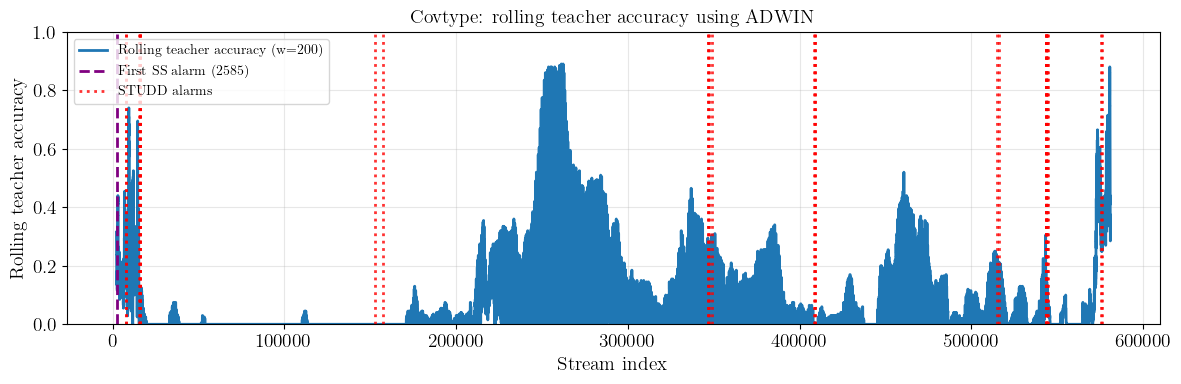

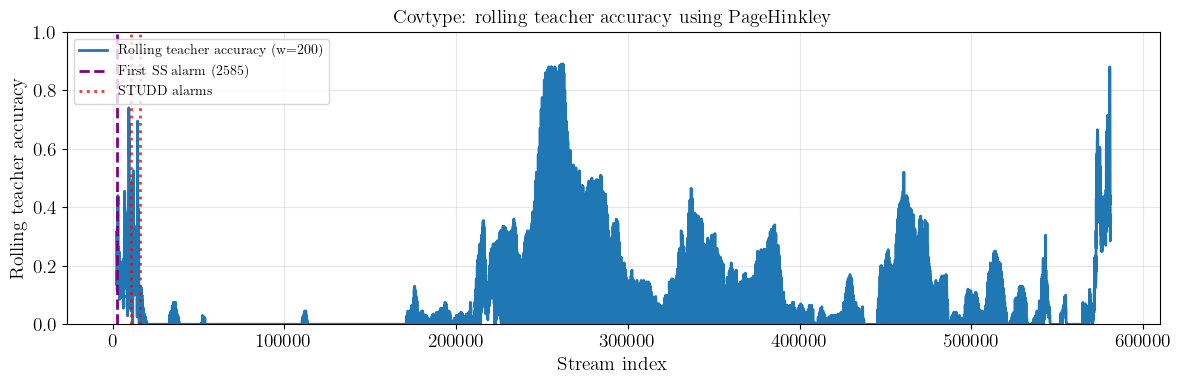

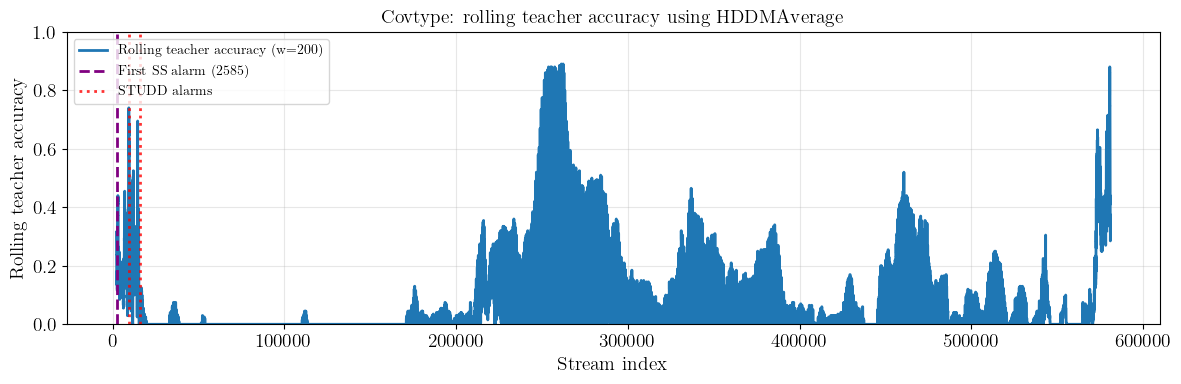

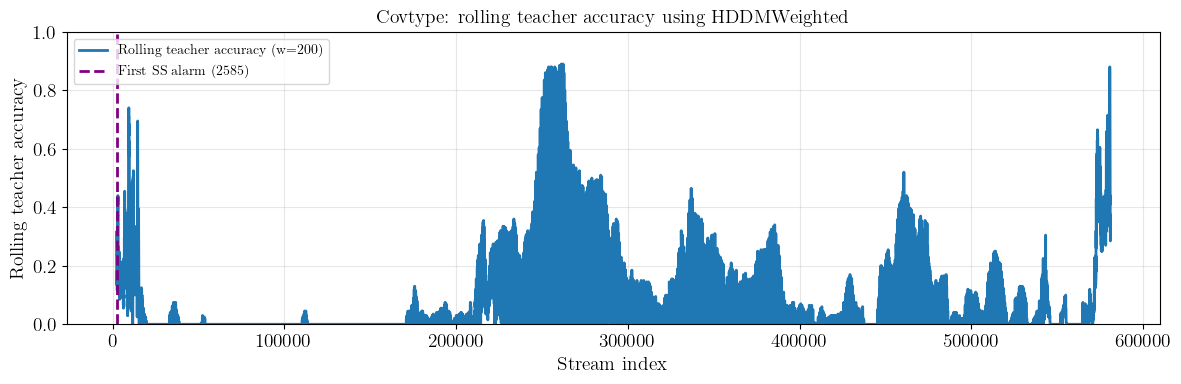

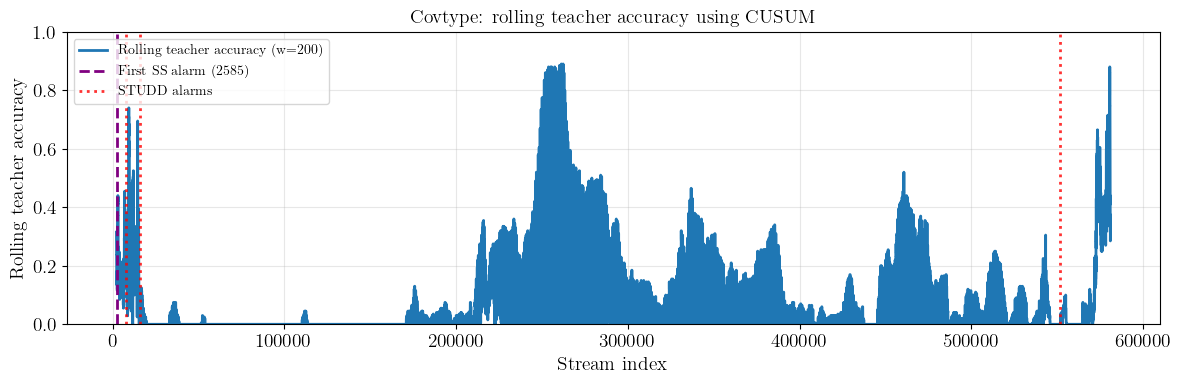

In [8]:
for detector_name, run in comparison_runs.items():

    results = run["results"]
    alarms = run["studd_drift_points"]

    rolling_accuracy, _ = rolling_mean(
        results["teacher_correct"].to_numpy(dtype=float),
        ROLLING_WINDOW,
    )

    rolling_t = results["t"].to_numpy()[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_accuracy,
        linewidth=2,
        label=f"Rolling teacher accuracy (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        reference_drift,
        color="purple",
        linestyle="--",
        linewidth=2,
        label=f"First SS alarm ({reference_drift})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"Covtype: rolling teacher accuracy using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling teacher accuracy")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Rolling teacher-student disagreement

The following plots show the rolling teacher-student disagreement for each detector.

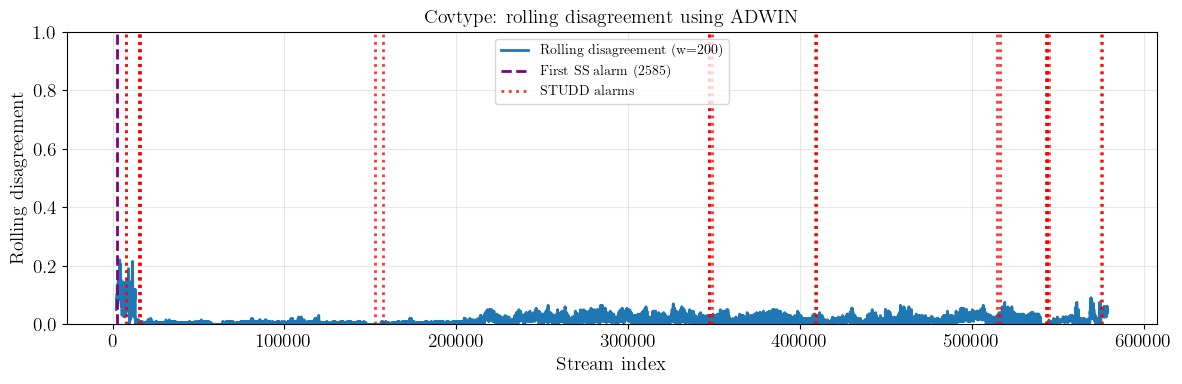

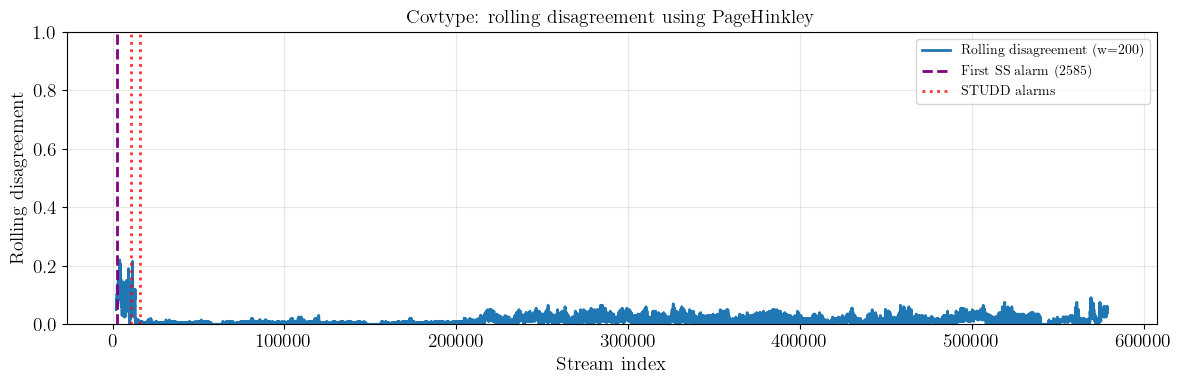

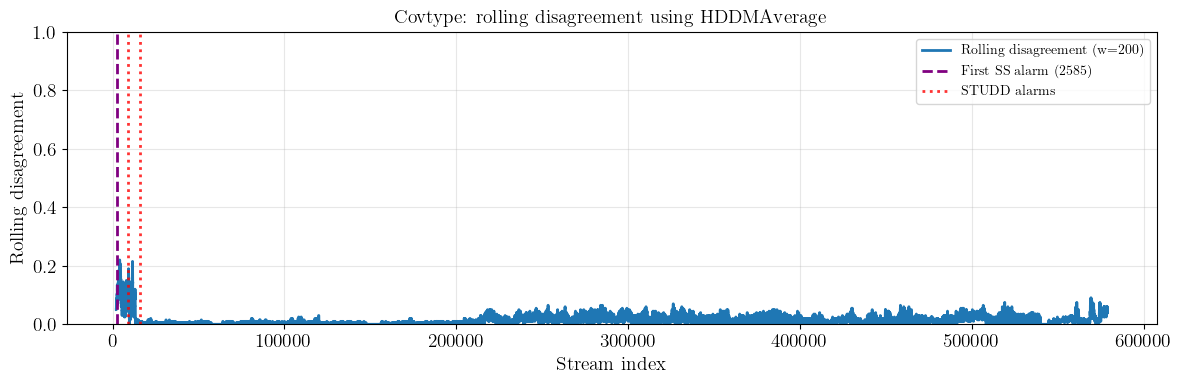

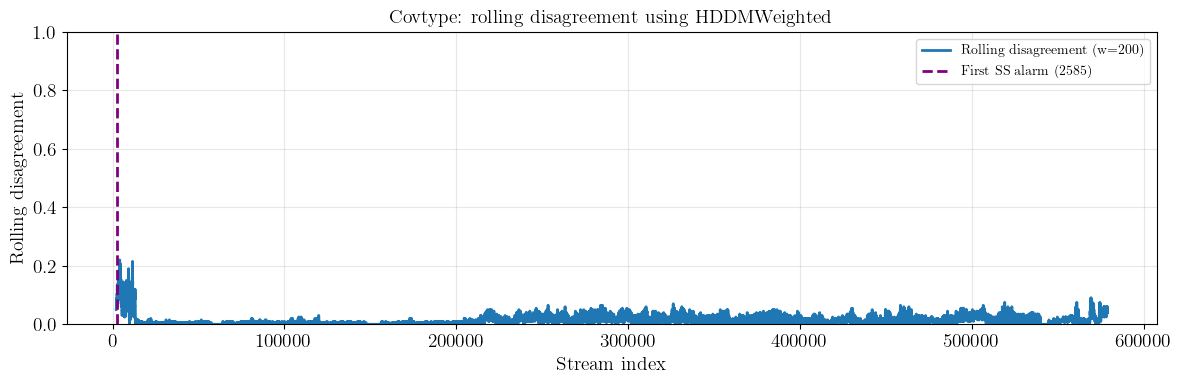

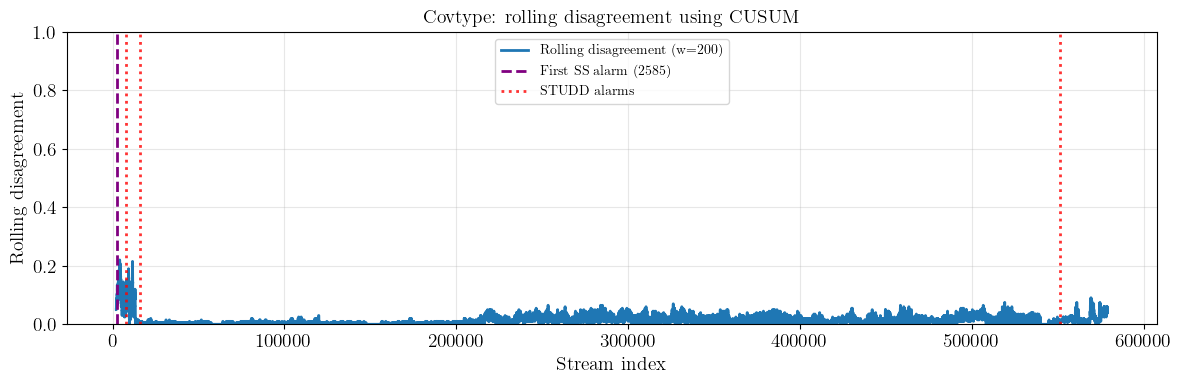

In [9]:
for detector_name, run in comparison_runs.items():

    agreement_idx = run["agreement_idx"]
    disagreement = run["disagreement"]
    alarms = run["studd_drift_points"]

    rolling_disagreement, _ = rolling_mean(
        disagreement,
        ROLLING_WINDOW,
    )

    rolling_t = agreement_idx[
        ROLLING_WINDOW - 1:
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        rolling_t,
        rolling_disagreement,
        linewidth=2,
        label=f"Rolling disagreement (w={ROLLING_WINDOW})",
    )

    plt.axvline(
        reference_drift,
        color="purple",
        linestyle="--",
        linewidth=2,
        label=f"First SS alarm ({reference_drift})",
    )

    for i, alarm in enumerate(alarms):
        plt.axvline(
            alarm,
            color="red",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="STUDD alarms" if i == 0 else None,
        )

    plt.title(f"Covtype: rolling disagreement using {detector_name}")
    plt.xlabel("Stream index")
    plt.ylabel("Rolling disagreement")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Interpretation

This notebook compares the effect of changing the detector inside STUDD on the Covtype dataset.

Since Covtype does not provide a true drift point, the first SS alarm is used as a reference drift indication.

The key quantities are:

- closest alarm distance from ss : how close the STUDD detector came to the SS reference alarm
- alarms before first ss : whether STUDD raised alarms before the supervised reference point
- number of alarms : whether the detector is too sensitive
- reference disagreement delta : whether disagreement changes around the first SS alarm
- closest alarm disagreement delta : whether disagreement changes around the closest STUDD alarm